# 📊 EXPECTATION_DECIDER_PROJECT

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

In [33]:
df = pd.read_csv("expectation_decider_dataset_150.csv")

In [34]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,5,51,No,66,Fail
1,9,58,Yes,46,Fail
2,20,77,Yes,38,Pass
3,4,63,Yes,99,Pass
4,2,85,Yes,88,Pass


# QUESTION NO 1 = UNDERSTANDING THE BASIC


# What is Probability?

Probability means the chance of occurrence of an event.

Formula:

P(E) = Favorable Outcomes / Total Outcomes

# Key Probability Terminology

1. Experiment:
Process of observing an outcome.

2. Outcome:
Result of an experiment.

3. Event:
Specific result or condition.

4. Random Variable:
Variable representing random values.

5. Conditional Probability:
Probability of an event given another event.

In [35]:
total_students = len(df)

print(total_students)

150


In [36]:
event1 = len(df[df['study_hours'] > 10])

prob_event1 = event1 / total_students

print(prob_event1)

0.4866666666666667


In [37]:
event2 = len(df[df['attendance'] > 80])

prob_event2 = event2 / total_students

print(prob_event2)

0.32666666666666666


In [38]:
event3 = len(df[df['final_exam_pass'] == 'Pass'])

prob_event3 = event3 / total_students

print(prob_event3)

0.72


# QUESTION NO 2 = Types of Events

# Empirical probability

In [39]:
pass_students = len(df[df['final_exam_pass'] == 'Pass'])

empirical_probability = pass_students / total_students

print(empirical_probability)

0.72


# Theoretical Probability

If there are only two equally likely outcomes:

Pass or Fail

P(Pass) = 1/2

# QUESTION NO 3 = random variable & probability distribution

Random Variable X = Number of students passing among 3 selected students.

In [40]:
# distribution table

distribution = {
    "X": [0,1,2,3],
    "P(X)": [0.10,0.20,0.40,0.30]
}

dist_df = pd.DataFrame(distribution)

dist_df

,X,P(X)
0,0,0.1
1,1,0.2
2,2,0.4
3,3,0.3


In [41]:
# mean calculation

x = np.array([0,1,2,3])

p = np.array([0.10,0.20,0.40,0.30])

mean = np.sum(x * p)

print(mean)

1.9


In [42]:
# variance calculation

variance = np.sum(((x - mean) ** 2) * p)

print(variance)

0.8899999999999999


# QUESTION NO 4 = VEHN DIAGRAM IN PROBABILITY

In [43]:
# STUDENT STUDY MORE THEN 10 HOURS

study_more_10 = df[df['study_hours'] > 10]

print(len(study_more_10))

73


In [44]:
# ATTENDANCE MORE THEN 80%

attendance_more_80 = df[df['attendance'] > 80]

print(len(attendance_more_80))

49


In [45]:
# STUDENT SATISFY BOTH CONDITIONS

both_conditions = df[
    (df['study_hours'] > 10) &
    (df['attendance'] > 80)
]

print(len(both_conditions))

27


In [46]:
# Set A
A = len(df[df['study_hours'] > 10])

# Set B
B = len(df[df['attendance'] > 80])

# Intersection
A_and_B = len(df[
    (df['study_hours'] > 10) &
    (df['attendance'] > 80)
])

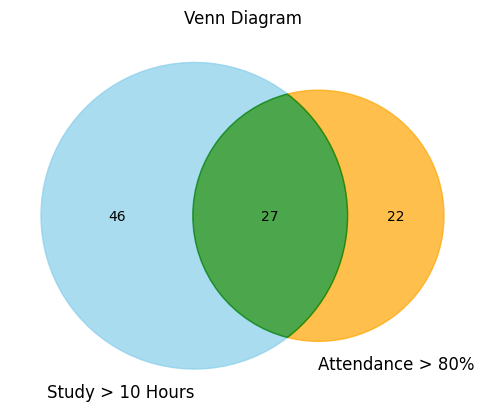

In [47]:
# Create VEHN DIAGRAM

plt.figure(figsize=(6,6))

v = venn2(
    subsets=(
        A - A_and_B,
        B - A_and_B,
        A_and_B
    ),

    set_labels=(
        'Study > 10 Hours',
        'Attendance > 80%'
    )
)

# Change Colors
v.get_patch_by_id('10').set_color('skyblue')

v.get_patch_by_id('01').set_color('orange')

v.get_patch_by_id('11').set_color('green')

# Transparency
v.get_patch_by_id('10').set_alpha(0.7)

v.get_patch_by_id('01').set_alpha(0.7)

v.get_patch_by_id('11').set_alpha(0.7)

plt.title("Venn Diagram")

plt.show()

# QUESTION NO 5 = Contingency Table & Probability Calculations

In [48]:
# CONTINGENCY TABLE

contingency_table = pd.crosstab(
    df['group_discussion'],
    df['final_exam_pass']
)

print(contingency_table)

final_exam_pass   Fail  Pass
group_discussion            
No                  30    51
Yes                 12    57


In [49]:
# JOINT PROBABILITY

joint = len(df[
    (df['group_discussion'] == 'Yes') &
    (df['final_exam_pass'] == 'Pass')
])

joint_probability = joint / total_students

print(joint_probability)

0.38


In [50]:
# MARGINAL PROBABILITY

marginal_probability = pass_students / total_students

print(marginal_probability)

0.72


In [51]:
# CONDITIONAL PROBABILITY

discussion_students = len(
    df[df['group_discussion'] == 'Yes']
)

conditional_probability = joint / discussion_students

print(conditional_probability)

0.8260869565217391


# QUESTION NO 6 = Understanding Relationships

# Relationship Analysis

Students participating in group discussions have higher probability of passing.

Therefore, both events are dependent events.

# QUESTION NO 7 = ayes Theorem Application

In [52]:
P_H_given_P = 0.70

P_H_given_F = 0.40

P_H = 0.60

P_Pass = 0.60

In [53]:
bayes = (P_H_given_P * P_Pass) / P_H

print(bayes)

0.7


# FINAL CONCLUSION


Students with:

- Higher study hours
- Better attendance
- Group discussion participation
- Higher previous test scores

have greater probability of passing the final exam.